**Business Problem**

Lenders (like banks or microfinance institutions) face credit risk when they approve loans. Some borrowers repay on time, while others default or struggle to repay. Defaults reduce profitability and increase losses.

This dataset captures customer information (demographics, financial details, credit history, etc.) and whether they had repayment difficulty (Default = 0/1).
**The business problem** is:

Which factors are most important when predicting the likelihood of loan default?
This project seeks to create a Loan Default Prediction Algorithm

The dataset used is https://www.kaggle.com/datasets/nikhil1e9/loan-default


***IMPORT LIBRARIES***

In [ ]:
#Data Analysis Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Modelling Libraries
from sklearn.model_selection import train_test_split # Splits data into Train and test sets
from sklearn.compose import ColumnTransformer # Column transformation e.g scaling, encoding
from sklearn.preprocessing import OneHotEncoder # Encoding categorical variables that don't have a ranking e.g colors, car ownership etc
from sklearn.preprocessing import StandardScaler # Used to standardize/normalize features. Centers values to zero(mean of each will be zero)
from sklearn.impute import SimpleImputer # replaces missing entries with imputed values based on a specified strategy.
from sklearn.pipeline import Pipeline #serves to streamline machine learning workflows by chaining together multiple steps into a single, cohesive object.

# Importing Models
from sklearn.linear_model import LogisticRegression
# statistical model used for binary classification (predicting one of two outcomes)
#and can also be extended for multi-class classification.
from sklearn.ensemble import RandomForestClassifier
#Imports random forest classifier, a machine learning algorithm that uses an ensemble of decision trees to classify data
import xgboost as xgb
#Importing Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay, classification_report
)


***Mount Drive***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


***LOAD DATASET***

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Loan_default.csv')
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


**PREPROCESSING**

In [ ]:
# Basic checks
rows, columns = (df.shape)
print(f"There are {rows} rows and {columns} columns")
print(df.Default.value_counts(dropna=False))


There are 255347 rows and 18 columns
Default
0    225694
1     29653
Name: count, dtype: int64


In [ ]:
#Check if there are missing values
df.isnull().sum().sum()

np.int64(0)

In [ ]:
#Drop unuseful Column, LoanID
df.drop(columns=['LoanID'], inplace=True)

In [ ]:
df.shape

(255347, 17)

In [ ]:
# 3) Feature/target split
TARGET_COL = 'Default'
X = df.drop(columns=[TARGET_COL]) # Sets apart all other columns except Default as independent Vars(x)
y = df[TARGET_COL].astype(int) # Sets apart TARGET_COL as Response/Dependent Vars(y)

In [ ]:
#Identify column types of predictor variables
categorical_cols=X.select_dtypes(include=['object', 'category']).columns
numeric_cols=X.select_dtypes(include=['number']).columns
CNTCatvars=len(categorical_cols)
CNTNumvars=len(numeric_cols)
print(f"Numeric: {CNTNumvars} | Categorical: {CNTCatvars}")

Numeric: 9 | Categorical: 7


In [ ]:
# 4) Preprocess pipelines =========
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))  #
])
#SimpleImputer(strategy="median")
#replaces any NaN in each numeric column with that column’s median (more robust to outliers than the mean).
# Standard scaler is necessary for Logistic regression transforms features to have a mean of zero and a standard deviation of 1

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

#fills NaN in each categorical column with that column’s most frequent value (the mode).
#Keeps every row usable; avoids dropping rows because of missing categories.

preprocess = ColumnTransformer(
    transformers=[("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)])
#Applies numeric_pipe to numeric_cols and categorical_pipe to categorical_cols,
#then concatenates the results into one feature matrix for the model.

In [ ]:
#  5) Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#It splits your data into training and test sets, Train=O.8, test=0.2
# stratify=y: preserves the class distribution of y in both splits (crucial here since Default=1 is ~11.6%).
# random_state=42: makes the split reproducible (same rows end up in train/test each run).


In [ ]:
#6A) Baseline model: Logistic Regression =========
log_reg = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(
        max_iter=10000,
        class_weight="balanced",   # helpful if classes are imbalanced/Automatically adjusts weights for underrepresented classes (1s/0s)
        n_jobs=None                # set to None for LR; use saga/lbfgs solver implicitly
    ))
])

#The "Prep" step applies preprocessing transformations (which is defined earlier with ColumnTransformer).
#After preprocessing, the transformed features are passed to a Logistic Regression classifier.
log_reg.fit(X_train, y_train)
proba_lr = log_reg.predict_proba(X_test)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

#This trains my pipeline: Then it fits the logistic regression model using y_train as the target.
#After this,the pipeline has “learned” the relationship between features and labels.

print("\n Logistic Regression Performance ")
print("Accuracy:", round(accuracy_score(y_test, pred_lr), 4))
print("Precision:", round(precision_score(y_test, pred_lr), 4))
print("Recall:", round(recall_score(y_test, pred_lr), 4))
print("F1:", round(f1_score(y_test, pred_lr), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_lr), 4))
print("\nClassification report:\n", classification_report(y_test, pred_lr, digits=4))



 Logistic Regression Performance 
Accuracy: 0.6764
Precision: 0.2197
Recall: 0.7001
F1: 0.3345
ROC-AUC: 0.7532

Classification report:
               precision    recall  f1-score   support

           0     0.9447    0.6733    0.7863     45139
           1     0.2197    0.7001    0.3345      5931

    accuracy                         0.6764     51070
   macro avg     0.5822    0.6867    0.5604     51070
weighted avg     0.8605    0.6764    0.7338     51070



In [ ]:
cm_lr = confusion_matrix(y_test, pred_lr)
print("Confusion Matrix:\n", cm_lr)

Confusion Matrix:
 [[30394 14745]
 [ 1779  4152]]


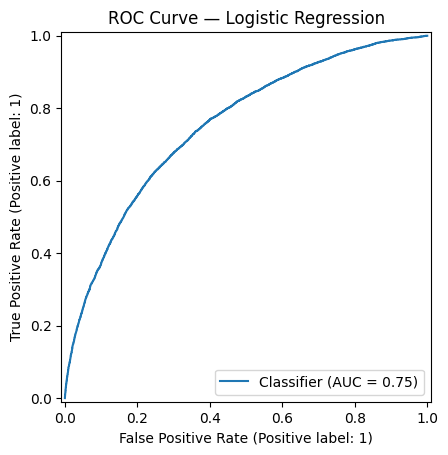

In [ ]:
RocCurveDisplay.from_predictions(y_test, proba_lr)
plt.title("ROC Curve — Logistic Regression")
plt.show()

In [ ]:
# 6B) Tree model: Random Forest =========
rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
pred_rf = (proba_rf >= 0.25).astype(int)

print("\n Random Forest Performance ")
print("Accuracy:", round(accuracy_score(y_test, pred_rf), 4))
print("Precision:", round(precision_score(y_test, pred_rf), 4))
print("Recall:", round(recall_score(y_test, pred_rf), 4))
print("F1:", round(f1_score(y_test, pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_rf), 4))
print("\nClassification report:\n", classification_report(y_test, pred_rf, digits=4))


 Random Forest Performance 
Accuracy: 0.8116
Precision: 0.2999
Recall: 0.4664
F1: 0.365
ROC-AUC: 0.7511

Classification report:
               precision    recall  f1-score   support

           0     0.9244    0.8569    0.8894     45139
           1     0.2999    0.4664    0.3650      5931

    accuracy                         0.8116     51070
   macro avg     0.6121    0.6616    0.6272     51070
weighted avg     0.8518    0.8116    0.8285     51070



In [ ]:
cm_rf = confusion_matrix(y_test, pred_rf)
print("Confusion Matrix:\n", cm_rf)

Confusion Matrix:
 [[38681  6458]
 [ 3165  2766]]


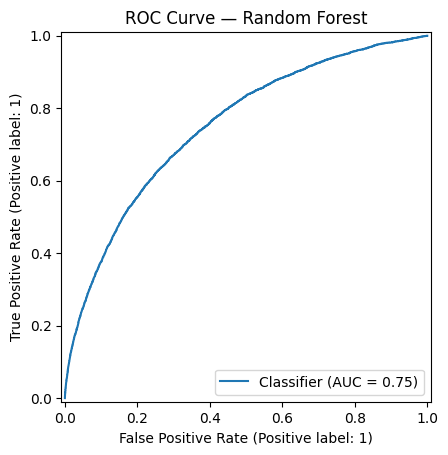

In [ ]:
RocCurveDisplay.from_predictions(y_test, proba_rf)
plt.title("ROC Curve — Random Forest")
plt.show()

**XGBoost Classifier**

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 7) Tree model: XGBoost
xgb = Pipeline(steps=[
    ("prep", preprocess),
    ("model", XGBClassifier(
        n_estimators=500,           # number of trees
        max_depth=5,                # depth of trees
        learning_rate=0.05,         # step size shrinkage
        subsample=0.8,              # row sampling
        colsample_bytree=0.8,       # feature sampling
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  # handle imbalance
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False     # avoid warning in newer versions
    ))
])

# Fit model
xgb.fit(X_train, y_train)

# Predictions
proba_xgb = xgb.predict_proba(X_test)[:, 1]
pred_xgb = (proba_xgb >= 0.5).astype(int)

# Evaluate
print("\n=== XGBoost Performance ===")
print("Accuracy:", round(accuracy_score(y_test, pred_xgb), 4))
print("Precision:", round(precision_score(y_test, pred_xgb), 4))
print("Recall:", round(recall_score(y_test, pred_xgb), 4))
print("F1:", round(f1_score(y_test, pred_xgb), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_xgb), 4))
print("\nClassification report:\n", classification_report(y_test, pred_xgb, digits=4))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:09:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost Performance ===
Accuracy: 0.7059
Precision: 0.2332
Recall: 0.6697
F1: 0.3459
ROC-AUC: 0.7566

Classification report:
               precision    recall  f1-score   support

           0     0.9424    0.7107    0.8103     45139
           1     0.2332    0.6697    0.3459      5931

    accuracy                         0.7059     51070
   macro avg     0.5878    0.6902    0.5781     51070
weighted avg     0.8601    0.7059    0.7564     51070



**XGBClassifier**


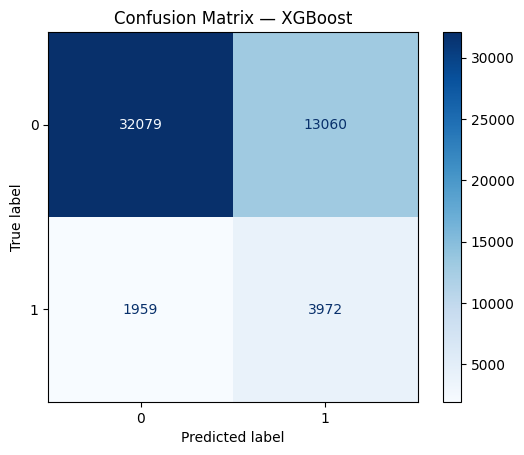

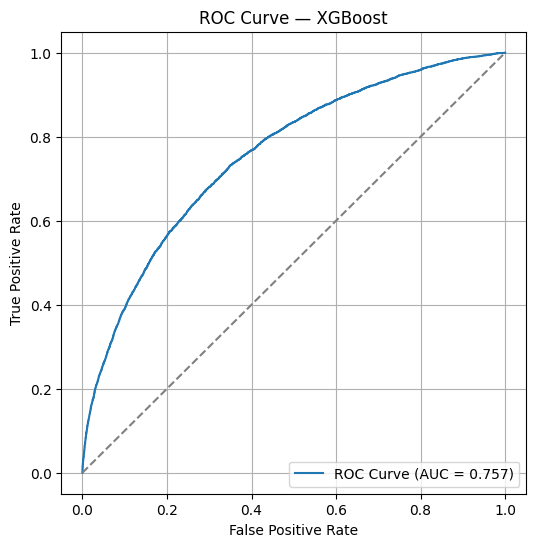

In [ ]:

# Confusion Matrix (using 0.5 threshold by default)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
cm = confusion_matrix(y_test, pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — XGBoost")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, proba_xgb)
auc_score = roc_auc_score(y_test, proba_xgb)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


**Performance comparison fo the three models**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    """
    Returns a dictionary of metrics for a fitted model.
    Works for models with predict_proba or decision_function.
    """
    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC-AUC (use decision_function if predict_proba not available)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

In [ ]:
results = {
    "Logistic Regression": evaluate_model(log_reg, X_test, y_test),
    "Random Forest": evaluate_model(rf, X_test, y_test),
    "XGBoost": evaluate_model(xgb, X_test, y_test)
}

df_results = pd.DataFrame(results).T  # transpose to have models in columns
df_results = df_results.round(2)      # format to 4 decimal places
print("Model Comparison")
print(df_results)


Model Comparison
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Logistic Regression      0.68       0.22    0.70      0.33     0.75
Random Forest            0.89       0.57    0.06      0.10     0.75
XGBoost                  0.71       0.23    0.67      0.35     0.76


**Feature Importance in the Logistic Model sorted from the most important features**

In [ ]:
import pandas as pd
from sklearn.inspection import permutation_importance

# log_reg is already fitted in your code
result = permutation_importance(
    log_reg,
    X_test,        # original test DataFrame
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

fi_perm = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

print(fi_perm)

           Feature  Importance
0              Age    0.030423
6     InterestRate    0.017989
4   MonthsEmployed    0.009920
2       LoanAmount    0.009097
1           Income    0.007932
10  EmploymentType    0.002240
9        Education    0.001406
15     HasCoSigner    0.001116
3      CreditScore    0.000975
13   HasDependents    0.000805
8         DTIRatio    0.000799
14     LoanPurpose    0.000470
12     HasMortgage    0.000305
5   NumCreditLines    0.000286
11   MaritalStatus    0.000049
7         LoanTerm   -0.000010


**EXPLANATION**
1. **Logistic Regression (Baseline)**

**Strengths**
High recall (0.70) → catches most of the minority class (1’s).

Simple and interpretable.

**Weaknesses:**

Very low precision (0.22) → lots of false positives.

Overall accuracy lower since it misclassifies many majority cases.

**NB** Best when the cost of missing a positive (false negative) is very high, e.g., loan default detection.

2. **Random Forest**

**Strengths**

Highest accuracy (0.89) and ROC-AUC (0.75).

Very strong at classifying majority class (0’s).

**Weaknesses:**

Low recall for minority class (0.06).

Identifies fewer actual positives (misses many).

 Best when minimizing overall error is most important, but not ideal if recall on minority class is critical.

**3. XGBoost**

**Strengths**:

Balanced performance: higher recall (0.67) than RF, better F1-score (0.35) than both others.

Precision better than Logistic Regression, though lower than RF.
ROC-AUC slightly bigger than the other two models.
**Weaknesses:**

Accuracy lower than Random Forest (but still good at 0.71).



 Best compromise model if you want to balance catching more positives and keeping false positives reasonable.

**✅ Recommendation**

If finding as many positives as possible is the priority → Logistic Regression (highest recall).

If overall accuracy and majority class prediction matter most → Random Forest.

If you need a balanced trade-off between recall, precision, and F1 → XGBoost is the best fit.

In this case, since the cost of missing a true positive is greater than incorrectly classifying a True negative as a True positive, a banking institution would prefer to adopt the Logistic regression as the Loan Default Prediction Algorithm